# **Rediscover the Higgs Boson Yourself - For Beginners**

<img src="https://github.com/atlas-outreach-data-tools/notebooks-collection-opendata/blob/master/images/ATLASOD.gif?raw=1\" width=50% />

This notebook uses the ATLAS Open Data http://opendata.atlas.cern 2025 beta release to show you the steps to rediscover the Higgs boson yourself!

ATLAS Open Data provides open access to proton-proton collision data at the LHC for educational purposes. ATLAS Open Data resources are ideal for high school, undergraduate and postgraduate students.

## **Overview**

This exercise is aimed towards those interested in experimental high-energy
physics with limited programming experience. Readers will be introduced to
Python and the needed packages (such as Uproot and NumPy) to complete
three activities:
1. Use real data to plot the masses of di-lepton systems to observe a peak at
the mass of the Z boson
2. Use simulated data to observe a peak at the mass of the Higgs boson
3. Use real data to observe a peak at the mass of the Higgs boson

## **Physics Context**

### **Mass and 4 Vectors**

*4-vectors* (also known as *Lorentz vectors*) are vectors used in relativistic calculations. They are defined by their ability to undergo *Lorentz transformations*. They have one time and three space components, as can be seen plainly in the *4-position* which records a location in spacetime.
\begin{equation}
\vec{S}=\begin{pmatrix}
t \\ x \\ y \\ z
\end{pmatrix}
\end{equation}
Notice the apparent inconsistency in the units of the components of $\vec{S}$: $t$ has units of time while $x$, $y$, and $z$ have units of length. In actuality, there is a hidden factor of the speed of light ($c$) such that the *4-position* is truly: 
\begin{equation}
\vec{S_1}=\begin{pmatrix}
ct \\ x \\ y \\ z
\end{pmatrix}
\end{equation}
As can be seen, all components have units of length. However, these factors of $c$ become numerous quickly, so physicists often simplify their calculations with a system of *natural units* where $c\equiv 1$. With this definition, no unit contradiction exists in $\vec{S}$ and $t$ now has units of length.

The 4-vectors that you will work with to rediscover the Higgs boson are *4-momentums*.
\begin{equation}
\vec{P}=\begin{pmatrix} E \\ p_x \\ p_y \\ p_z\end{pmatrix}
\end{equation}
For the *4-momentum*, the energy $E$ is the time component and the space components are the components of the *3-momentum* (the non-relativistic momentum $\begin{pmatrix} p_x & p_y & p_z\end{pmatrix}$.
Once again, the units are consistent because high-energy physicists measure both energy and momentum in terms of gigaelectron-volts (GeV).

The scalar product of two 4-vectors acts a little differently than other vectors. All the space quantities pick up a minus sign like so:
\begin{equation}
\vec{A} \cdot \vec{B}=\begin{pmatrix} A_0 \\ A_1 \\ A_2 \\ A_3 \end{pmatrix} \cdot \begin{pmatrix} B_0 \\ B_1 \\ B_2 \\ B_3 \end{pmatrix} = A_0 B_0 - A_1 B_1 - A_2 B_2 - A_3 B_3
\end{equation}
From this we can see that a 4-vector squared is:
\begin{equation}
(\vec{A})^2=\vec{A} \cdot \vec{A} = (A_0)^2 - (A_1)^2 - (A_2)^2 - (A_3)^2
\end{equation}
This quantity, the square of a 4-vector, is called the *invariant quantity* because it is invariant under Lorentz transformations. This means that if we were to look at a particle in different inertial frames moving with respect to each other, then write out the 4-vectors of the particle from each frame, and finally calculate the invariant quantity, we would end up with the same value every time.

The invariant quantity of the 4-momentum is:
\begin{equation}
(\vec{P})^2 = E^2 - p_x^2 - p_y^2 - p_z^2 = E^2-\textbf{p}\cdot\textbf{p}
\end{equation}
The mass of an object is not the "amount of stuff" that is in it, but rather its energy at rest. Note that mass in natural units is not measured in kilograms but rather in gigaelectron-volts just like momentum and energy. At rest, the 4-momentum of a particle is:
\begin{equation}
\vec{P}_{rest}=\begin{pmatrix} m \\ 0 \\ 0 \\ 0\end{pmatrix}
\end{equation}
And its square is:
\begin{equation}
(\vec{P})^2 = m^2 - 0 - 0 - 0 = m^2
\end{equation}
Since the square of a 4-vector is an invariant quantity, it is true in all frames, so the mass of any particle, given its 4-momentum is:
\begin{equation}\label{m}
m = \sqrt{E^2-\textbf{p}\cdot\textbf{p}}
\end{equation}
This is the relation that you will use to calculate the masses of the Z and Higgs bosons.

### **The Standard Model**

The *Standard Model* is the leading theory describing the *fundamental particles* and the forces that allow them to interact. *Fundamental particles* are not made up of smaller particles; they are the simplest building blocks of the universe. Shown below are the different types of fundamental particles. A majority of these have corresponding antimatter particles which are much like the matter particles but with opposite properties. As an example, the electron ($e^-$) and its antimatter equivalent, the positron ($e^+$), have the same mass and behavior but opposite charges.

<CENTER><img src="https://github.com/atlas-outreach-data-tools/notebooks-collection-opendata/blob/master/13-TeV-examples/uproot_python/images/ImagesHiggs/Standard_Model.png?raw=1\" width=40%"><CENTER>

In the following activities, you will be working with four different kinds of particles: electrons ($e$), muons ($\mu$) (both matter and antimatter variants), Z bosons and Higgs bosons. Electrons and muons are members of a subset of particles called leptons. Both particles are of charge -1 (meaning their anti-particles are both of charge +1) and have a longer lifespan than the Z and Higgs Bosons. The Z boson is a neutral particle (a particle of zero charge) that mediates the *weak interaction*. The Higgs boson is a neutral particle that *couples* to other particles to give them mass. 

### **Decay Modes**

Fundamental particles can spontaneously transform into multiple other particles in a process called *particle decay*. The *decay modes* of a particle are the various ways in which a particle can decay. There are only a few decay modes that you need to know for the purpose of completing this exercise. A more complete list can be found at the [*Particle Data Group*](https://pdg.lbl.gov/).


The Z boson decays into two leptons of the same flavor (meaning both electrons and both muons) and opposite charges. Thus, the two Z boson decay modes (that are relevant for this exercise) are: $Z\rightarrow e^+e^-$ and $Z\rightarrow \mu^+\mu^-$. Due to their short lifespans (the time that a particle exists before it decays), the ATLAS detector cannot directly detect Z bosons. Instead, we take advantage of the law of conservation of momentum to observe them. The 4-momentum of a particle undergoing particle decay is conserved, so if we can confirm that two leptons likely came from a Z boson, the sum of the their 4-momentums is equal to the 4-momentum of the Z boson they decayed from, which we can then use to calculate the mass.

The Higgs boson decays into two Z bosons (among other things). One of these Z bosons is an *off-shell* or *virtual* Z boson, meaning it has less mass than we would expect. A typical Z boson has a mass of around 91 GeV while the off-shell Z boson can have a variety of masses averaging around 34 GeV. The reason these off-shell Z bosons are able to exist is by borrowing the needed energy from the vacuum before quickly decaying into more stable particles. The reason they are able to do this is due to *Heisenberg's Uncertainty Principle* which sets limits on the accuracy that pairs of physical properties can be measured. The energy-time uncertainty relation is shown below:
\begin{equation}
\Delta E \cdot \Delta t \ge \frac{\hbar}{2}
\end{equation}
The other Z boson is referred to as *on-shell* to signify that it has the expected amount of mass. Both Z bosons decay as described above into two leptons each. Thus, the four Higgs boson decay modes are: 
1. $H\rightarrow ZZ^*\rightarrow e^+e^-e^+e^-$
2. $H\rightarrow ZZ^*\rightarrow e^+e^-\mu^+\mu^-$
3. $H\rightarrow ZZ^*\rightarrow \mu^+\mu^-e^+e^-$
4. $H\rightarrow ZZ^*\rightarrow \mu^+\mu^-\mu^+\mu^-$

<CENTER><img src="https://github.com/atlas-outreach-data-tools/notebooks-collection-opendata/blob/master/13-TeV-examples/uproot_python/images/ImagesHiggs/HZZ_feynman.png?raw=1\" width=60%"><CENTER>

Much like the Z boson, we will not be directly observing the Higgs Boson in ATLAS open data, instead, we will look for 4 leptons that meet all the characteristics of leptons which would have decayed from a Higgs boson, then we will add together their 4-vectors to obtain a 4-vector for the Higgs boson they decayed from.

### **Pseudorapidity**

ATLAS records the momentum of the particles it detects in a special coordinate system based in *pseudorapidity*. The *pseudorapidity* ($\eta$) is defined as follows:
\begin{equation}
\eta = -ln[tan(\frac{\theta}{2})]
\end{equation}
$\theta$ is the angle between the beam and the 3-momentum. As $\theta$ varies from $0$ to $\pi$, $\eta$ varies from $\infty$ to $-\infty$. The reason that we use pseudorapidity $\eta$ as opposed to the angle $\theta$ is because $\theta$ is not invarient under Lorentz transformations while $\eta$, while technically also not invarient, is an approximation of the rapidity which is invarient.

Detector information in pseudorapidity coordinates can be converted to Cartesian coordinates with the following formulas:
\begin{equation}
 p_x = p_\perp \cos(\phi)   
\end{equation}
\begin{equation}
 p_y = p_\perp \sin(\phi)   
\end{equation}
\begin{equation}
 p_z = p_\perp \sinh(\eta)   
\end{equation}
 The $\hat{z}$ direction is the direction of the proton beam created by the LHC. $p_\perp$ is the component of the momentum perpendicular to the beam. $\phi$ is the angle between $p_\perp$ and the $\hat{x}$ direction.

The pseudorapidity coordinates and their relationships to the Cartesian coordinates are depicted below.

<CENTER><img src="https://github.com/atlas-outreach-data-tools/notebooks-collection-opendata/blob/master/13-TeV-examples/uproot_python/images/ImagesHiggs/prcoords.png?raw=1\" width=60%"><CENTER>

## **Python**

### **The Basics**

This exercise requires a basic understanding of Python topics like ints, boolean conditions, lists, dictionaries, and loops. If you are unfamiliar with Python, read through the [HSF Python tutorial](https://hsf-training.github.io/analysis-essentials/index.html). This tutorial will provide code segments in the form of Jupyter Notebook cells that you can follow along with to get practice. The HSF tutorial includes some topics like histogramming, scripting, and classes that, while are useful to a Python beginner, are not necessary to complete this exercise. You may skim through these parts.

### **NumPy**

NumPy is a popular and flexible package for data analysis, linear algebra, and much more. NumPy allows us to create multi-dimensional arrays with the *ndarray* object. *Ndarrays* are useful because they work much faster than typical Python lists and NumPy functions can be used to apply operations to the entirety of the array rather than one element at a time.

You can import NumPy like so:

In [1]:
import numpy as np

You can create an array using *np.array()* with a list as an argument like so:

In [2]:
a = np.array([1,4,9,16,25])

When we do math with ndarrays, the operation is applied to each component individually. As an example, the cell below returns a copy of *a* with *5* added to every element.

In [3]:
a+5

array([ 6,  9, 14, 21, 30])

NumPy also provides a huge library of math functions that can be applied component-wise. The cell below returns a copy of *a* with the square root of each element.

In [4]:
np.sqrt(a)

array([1., 2., 3., 4., 5.])

NumPy can also do component-wise math with two arrays. If we define two arrays, *a* and *b*, with the same shape, corresponding components can be added, subtracted, multiplied, or divided like so:

In [5]:
a = np.array([[1,2,3],[4,5,6]])
b = np.array([[7,8,9],[10,11,12]])
a+b #or a-b, a*b, a/b 

array([[ 8, 10, 12],
       [14, 16, 18]])

This is different than how typical Python lists are added, where they are stitched together into a larger list. To accomplish this with ndarrays, we can use the method *np.concatenate()* with all of the lists that we want to stitch together grouped in square brackets as one argument. We can specify the *axis* which we stitch the lists together; observe the difference between *axis=0* and *axis=1*.

In [6]:
np.concatenate([a,b],axis=0)

array([[ 1,  2,  3],
       [ 4,  5,  6],
       [ 7,  8,  9],
       [10, 11, 12]])

In [7]:
np.concatenate([a,b],axis=1)

array([[ 1,  2,  3,  7,  8,  9],
       [ 4,  5,  6, 10, 11, 12]])

Another useful application of this axis in ndarrays is the ability to sort arrays along their columns or rows using *np.sort()*. Once again, observe the difference in the output between *axis=0* and *axis=1*. 

In [8]:
# create an array of random integers
a = np.random.randint(low=0, high=10, size=(5,5))
a

array([[1, 3, 6, 8, 1],
       [3, 6, 7, 1, 4],
       [0, 9, 7, 7, 4],
       [7, 0, 1, 1, 0],
       [3, 6, 2, 9, 9]], dtype=int32)

In [9]:
np.sort(a,axis=0)

array([[0, 0, 1, 1, 0],
       [1, 3, 2, 1, 1],
       [3, 6, 6, 7, 4],
       [3, 6, 7, 8, 4],
       [7, 9, 7, 9, 9]], dtype=int32)

In [10]:
np.sort(a,axis=1)

array([[1, 1, 3, 6, 8],
       [1, 3, 4, 6, 7],
       [0, 4, 7, 7, 9],
       [0, 0, 1, 1, 7],
       [2, 3, 6, 9, 9]], dtype=int32)

To learn more about NumPy, consult the [website](https://numpy.org/). There, they have a *getting started* tutorial and extensive documentation on all the methods included.

## **Activity 1: Z Peak**

In this activity, you will:
1. Turn ATLAS open data into arrays that can be used in Python.
2. Create selections to remove any events that did not contain a Z
boson.
3. Use the properties of 4-vectors to calculate the masses of the Z
bosons.
4. Plot the masses of the Z bosons.

To begin, import the necessary libraries.

In [11]:
import numpy as np
import uproot # used for opening .root files
import matplotlib.pyplot as plt # used for drawing plots
import matplotlib.text # used for adding text to plots

This cell only needs to be run on your computer one time ever. 

### **Using ATLAS Open Data**

To open a file, you need to either have a root file stored to your hard drive or a url for a file stored on the internet. You will be importing our data from the ATLAS experiment using the package ATLAS Open Magic. Further information on the package can be found [here](https://opendata.atlas.cern/docs/data/atlasopenmagic). First, install the data to your computer (if you have not done so already). This can be done by executing the cell:

In [ ]:
import sys
%pip install atlasopenmagic
from atlasopenmagic import install_from_environment
install_from_environment()

Next, import the *atlasopenmagic* package as *atom* and set the available release using *atom.set_release()*. If you want to see all your options for the release, run *atom.available_releases()*.

In [12]:
import atlasopenmagic as atom
# you can change the release here
atom.set_release('2025e-13tev-beta')

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████████████████████████████████████████████████| 374/374 [00:00<00:00, 530.87datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


Now, we will access a list of files from the release. We first need to set the *skim*. The *skim* is essentially a filter for the type of data you want to open. You can check all your options for the *skim* by running *atom.available_skims()*. Now, define a list of files with the value returned by the method *atom.get_urls()*.

In [13]:
# the skim only pulls out events with 2 to 4 leptons
skim = '2to4lep'
files_list = atom.get_urls('data', skim, protocol = 'https', cache=True)

As can be seen below, *files_list* is a list of 16 web addresses of .root files. These can be opened and analyzed with *uproot*.

In [14]:
files_list

['simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2to4lep_data15_periodD.2to4lep.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2to4lep_data15_periodE.2to4lep.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2to4lep_data15_periodF.2to4lep.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2to4lep_data15_periodG.2to4lep.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2to4lep_data15_periodH.2to4lep.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2to4lep_data15_periodJ.2to4lep.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2to4lep_data16_periodA.2to4lep.root',
 'simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_2to4lep_data16

### **Using Uproot**

Uproot is a Python package used for reading ROOT files in Python. A more extensive look at its usage can be found at the [Uproot documentation](https://uproot.readthedocs.io/en/latest/index.html).

To open a file, use *uproot.open()*. Let's examine the file at index zero and store this value in a variable.

In [15]:
tree_dict = uproot.open(files_list[0])

ROOT files store data in what are called TTrees. They have various TBranches corresponding to different types of data collected. *tree_dict* is a dictionary of TTrees; call *tree_dict.keys()* to see the names of the different TTrees.

In [16]:
tree_dict.keys()

['analysis;1']

To access a single TTree, run *tree_dict['name of the TTree']*. In the case of ATLAS open data, all choices of skim will result in a dictionary with only one TTree called *analysis*. Since we know the name of the TTree before we open the file, we can take a shortcut to open the TTree directly by running:

In [17]:
analysis = uproot.open(files_list[0] + ':analysis')

To see the branches of *analysis*, run *analysis.show()*. If you are familiar with ROOT, think of this method as the Uproot equivalent of the TBrowser. It is less interactive but provides all the information needed about the ROOT file. If all the information is too overwhelming, you can filter for only branches with information about leptons by adding *filter_name = 'lep_$*$'* into the argument of the function to only display TBranches with names starting with *lep_*. 

In [18]:
analysis.show(filter_name = 'lep_*')

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
lep_n                | int32_t                  | AsDtype('>i4')
lep_type             | RVec<int32_t>            | AsJagged(AsDtype('>i4'), he...
lep_pt               | RVec<float>              | AsJagged(AsDtype('>f4'), he...
lep_eta              | RVec<float>              | AsJagged(AsDtype('>f4'), he...
lep_phi              | RVec<float>              | AsJagged(AsDtype('>f4'), he...
lep_e                | RVec<float>              | AsJagged(AsDtype('>f4'), he...
lep_charge           | RVec<int32_t>            | AsJagged(AsDtype('>i4'), he...
lep_ptvarcone30      | RVec<float>              | AsJagged(AsDtype('>f4'), he...
lep_topoetcone20     | RVec<float>              | AsJagged(AsDtype('>f4'), he...
lep_z0               | RVec<float>              | AsJagged(AsDtype('>f4'), he...
lep_d0               | RVec<float>          

Now that you have a TTree, you need to turn it into a data type that you can work with in Python. To do this, use the method *uproot.arrays()*. You must define two variables that we will use as arguments in the function. The first is an array of all the branches in the TTree that you want to analyze given whatever names you desire. It is easiest to simply remove the '*lep_*' from the branch name, so *lep_pt* simply becomes *pt*. The second is a dictionary that connects each of the chosen names as keys to the corresponding branches as values. The branches that you will need for your analysis are:
- Transverse momentum (lep\_pt)
- Pseudorapidity (lep\_eta)
- Angle around the beam (lep\_phi)
- Energy (lep\_e)
- Charge (lep\_charge)
- Flavor (lep\_type)
- Tight ID (lep\_isTightID)

A note on lepton flavor: ATLAS records the flavor of a lepton in the branch *lep_type*, but *type()* is already a function in Python that returns the data type of a variable. For this reason, you must call this attribute something other than type.

In [19]:
attributes = ['pt','eta','phi','e','charge','flavor','isTightID']
aliases_dict = {'pt':'lep_pt','eta':'lep_eta','phi':'lep_phi','e':'lep_e',
                               'charge':'lep_charge','flavor':'lep_type','isTightID':'lep_isTightID'}
leps = analysis.arrays(attributes, aliases = aliases_dict)

*leps* is a structured array managed by the Awkward Array package, which is the closest thing Python has to a TTree. Awkward Array works similar to NumPy but with less stringent rules regarding jagged arrays. Since the arrays start out initially as jagged arrays (since there are an inhomogeneous number of leptons in any given event) it is advantageous to start by working with this data type. A structured array is divided into fields (which can be displayed with *leps.fields*) similar to a dict. 

In [20]:
leps.fields

['pt', 'eta', 'phi', 'e', 'charge', 'flavor', 'isTightID']

All of the data from the field *'pt'* can be accessed using either *leps.pt* or *leps['pt']*. pt (and e) are stored in units of GeV.

In [21]:
leps.pt

<Array [[39.4, 42.3], [...], ..., [13.1, 26.2]] type='880210 * var * float32'>

All of the values for each field for the first event can be accessed using *leps[0]* (and likewise with subsequent events).

In [22]:
leps[0]

<Record {pt: [39.4, ...], eta: [...], ...} type='{pt: var * float32, eta: v...'>

All of the values for the first lepton in every event can be accessed using *leps[;,0]* (and likewise for subsequent leptons).

In [23]:
leps[:,0]

<Array [{pt: 39.4, eta: -1.46, ...}, ...] type='880210 * {pt: float32, eta:...'>

### **Getting Z Masses**

Now, you will examine the charge, flavor, and tight ID of the first two leptons in each event to determine whether or not they could have come from a Z boson decay. You will create lists of boolean values, called selections or cuts, that can be applied to our array to remove all leptons that do not meet the characteristics of leptons that decayed from a Z boson. 

Before creating selections, you must first sort each event in leps from highest to lowest transverse momentum. The two highest $p_\perp$ leptons are called the leading and sub-leading leptons and they are the leptons which will have decayed from a Z if a Z was present. To do this, you will need to create a sort of blueprint on how to sort the transverse momentum and then apply that blueprint to the whole structured array. This can be done using *np.argsort()* which returns an array of indices sorted from lowest to highest. See the example shown below.

In [24]:
a = np.array([16,22,49,7,23,11,15,33])
np.argsort(a)

array([3, 5, 6, 0, 1, 4, 7, 2])

You will need to define the *axis* of the function as *1* so that each event is sorted separately. The array needs to be sorted from highest to lowest a slice will need to be used to reverse the array along axis 1. The appropriate slice is *[:,::-1]*.The notation to reverse an array is *[::-1]*. Since we can access elements in the structured array leps like *leps[event \#, lepton \# within event]*, the slice to reverse the order of each event is *[:,::-1]*.

In [25]:
sorter = np.argsort(leps.pt,axis=1)[:,::1]

Now that you have created your blueprint, you can apply it to all of leps and then remove any leptons other than the leading and subleading leptons.

In [26]:
leps = leps[sorter][:,:2]

Now we can create the cuts. All charges are either +1 or -1, so the sum of the charges in each given event should be zero if a Z boson was present. The flavors are either 11 (electron) or 13 (muon). The value stored for flavor should be the same for the two leptons in each event with a Z boson. The tight ID of a given lepton is simply a boolean condition that states whether or not it can be said with certainty that a given detection was a lepton as opposed to a shower from the background. It should be true for both leptons in the event. Use this information to create 1D arrays of boolean conditions that return *True* for events that satisfy the condtion and *False* otherwise.

In [27]:
charge_cut = leps.charge[:,0] + leps.charge[:,1] == 0
flavor_cut = leps.flavor[:,0] == leps.flavor[:,1]
tight_cut = (leps.isTightID[:,0]) & (leps.isTightID[:,1])

As previously discussed, the energy and momentum of a particle undergoing decay is conserved. This means that the sum of the 4-momentum components of the leading and sub-leading leptons yields the 4-momentum components of the original Z boson. To create this, first calculate the the momentum in the x, y and z directions using the pseudorapidity to cartesian coordinate conversions.

In [28]:
px = leps.pt*np.cos(leps.phi)
py = leps.pt*np.sin(leps.phi)
pz = leps.pt*np.sinh(leps.eta)

Now create the components of the 4-momentum for the di-lepton system. You must do this by adding each component for the first lepton in each event to the second lepton of each event.

In [29]:
sum_px = px[:,0] + px[:,1]
sum_py = py[:,0] + py[:,1]
sum_pz = pz[:,0] + pz[:,1]
sum_e = leps.e[:,0] + leps.e[:,1]

Finally, calculate the masses of the Z bosons using the formula: $m=\sqrt{E^2-\textbf{p}\cdot\textbf{p}}$

In [30]:
masses = np.sqrt(np.abs(sum_e**2-sum_px**2-sum_py**2-sum_pz**2))

#### **Bonus Activity**

Rather than calculating mass using ndarrays as was shown above, high-energy physicists will instead use the vector to perform 4 vector calculations. All of the necessary information on vector can be found in the [vector documentation](https://pypi.org/project/vector/). Once you are familiar with 4 vector math, use the package vector to calculate the masses of the Z bosons.

### **Plotting Z Masses**

Before plotting, create a cell to apply the cuts to *masses*. Try graphing the data with and without executing this cell. The array *masses* can be reset to a pre-cut version by running the cell where it was originally created.

In [31]:
masses = masses[charge_cut & flavor_cut & tight_cut]

Matplotlib is a package used to plot data. All sorts of plots can be created but you will only need to know about histograms and error bar plots. For a more complete picture of what can be done with Matplotlib, refer to the [Matplotlib documentation](https://matplotlib.org/stable/).

The data can be plotted as a histogram using the method *plt.hist()*. In the arguments of the function, the data, number of bins, and range of the plot should be specified. The plot can then be displayed using *plt.show()*.

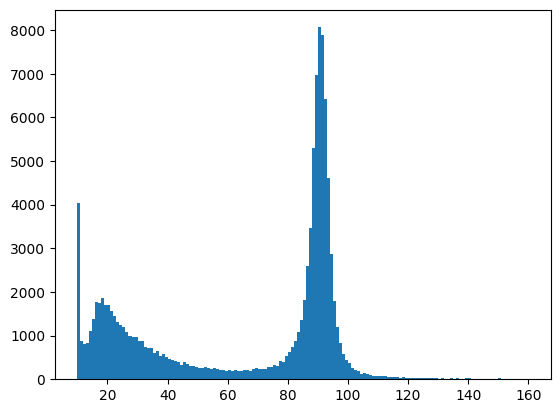

In [32]:
plt.hist(masses, bins=150, range=(10,160))
# additional info
plt.show()

The additional info in between the creation of the histogram and its display can include labeling the plot, labeling the axes, adding text and additional graphics to the plot, the creation of a legend, and many more actions that can be found in the Matplotlib documentation.

When working with real data, there is a degree of uncertainty in all of our measurements that must be taken into account and properly portrayed. This is a feature that is lacking in the histogram, so we plot our data as a scatter plot with error bars. To begin, define parameters controlling the upper and lower bounds of the graph and the width of each bin. The reason that these are defined first is because they will be called multiple times throughout the creation of the plot and having their definitions at the beginning of that process makes it very easy to change them.

In [33]:
x_min, x_max = 10,160
bin_width = 1

Now, you will create the bins. You will do this with two arrays, one to define the edges of the bins and one to record all of the values at the centers of the bins. The first array can be created using *np.arange()*, which requires a start value, an end value (which is not included in the array), and a step size. These are the three parameters that we defined previously. When we create a scatterplot, we want to put a point in the center of each bin; thus, we need an array to contain all of these values. To create it, simply shift the bin starting values (all of the edges except for the last one) to the right by half of a bin's width.

In [34]:
bin_edges = np.arange(start = x_min, stop = x_max+1, step = bin_width)
bin_centers = bin_edges[:-1] + bin_width/2

Next, group the data into the bins that we defined using the function *np.histogram()*. This function takes two arguments: an array of data, and a definition of the bins. Two values are returned so you must declare two variables to hold the values. However, the second value simply returns the bin edges, which has already been defined, so it is not needed. It is common in Python to name a variable that we will not use and don't care about \_.

In [35]:
counts, _ = np.histogram(masses, bins=bin_edges)

The length of the error bars for a distribution with discrete counts as its y axis values can be found by using a Poisson Distribution. The uncertainty in the counts $\nu$ in a Poisson distribution are:
\begin{equation}
\delta \nu = \sqrt{\nu}
\end{equation}
Thus, the lengths of the error bars of data can be found using *np.sqrt()*.

In [36]:
count_errors = np.sqrt(counts)

Finally, an error bar plot can be created using *np.errorbars()*. The x-axis will be the centers of the bins, the y-axis will be the counts in each bin, and the y-errors will be the errors we found using the Poisson distribution. Setting *fmt* to *'ko'* will simply determine the format of the plot. The plot is colored black by *'k'* and set to circles with points by *'o'*. The plot can be displayed by calling *plt.show()*.

All of the previous steps should be grouped into one cell. Additional info has been added between *plt.errorbars()* and *plt.show()* to display a Z-peak with all of the appropriate labels on the axes and plot.

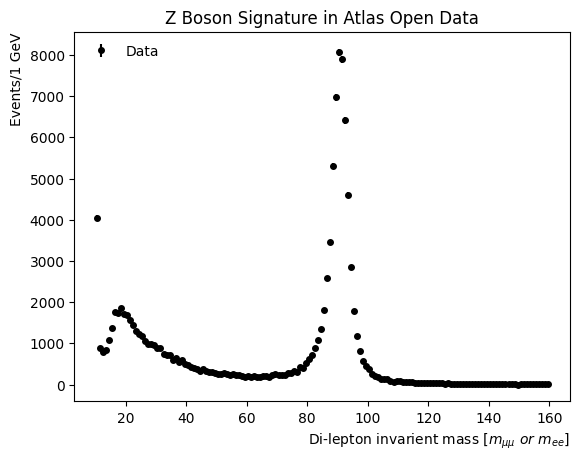

In [37]:
# initial parameters
x_min, x_max = 10,160
bin_width = 1
bin_edges = np.arange(start = x_min, stop = x_max+1, step = bin_width)
bin_centers = bin_edges[:-1] + bin_width/2
counts, _ = np.histogram(masses, bins=bin_edges)
count_errors = np.sqrt(counts)

#plot
plt.errorbar(x = bin_centers, y = counts, yerr = count_errors, fmt = 'ko', label = 'Data', markersize = 4)
plt.title('Z Boson Signature in Atlas Open Data')
plt.xlabel('Di-lepton invarient mass [${m_{\mu\mu} \ or \ m_{ee}}$]', x=1, horizontalalignment = 'right')
plt.ylabel('Events/' + str(bin_width) + ' GeV', y=1, horizontalalignment = 'right')
plt.legend(frameon = False, loc = 'upper left')
plt.show()

## **Activties 2: Higgs Peak from a Monte Carlo Simulation**

In this activity, you will:
1. Turn the file into Arrays that can be used in Python.
2. Structure our data in a way to represent all possible Z boson combinations.
3. create cuts to remove all invalid Z bosons.
4. Use the properties of 4-vectors to calculate the masses of the possible Z bosons.
5. Plot the masses of the possible Z bosons.
6. Use the Z boson masses and cuts to create more cuts to remove all invalid Higgs bosons.
7. Calculate the masses of the possible Higgs bosons.
8. Plot the masses of the Higgs bosons.

### **Obtaining the Data**

Ensure that the cells importing the necessary packages from Activity 1 are executed.

Now that we are searching for Higgs bosons, we have no need events with less than 4 leptons, so we can change the skim to *'4lep'*. Rather than working with *'data'*, we want to work with a simulation. For this reason, replace *'data'* with *'345060'* as an argument in *atom.get_urls()*. This is the dataset ID for the decay of a Higgs boson into 4 leptons. The complete list of dataset IDs can be found on [Monte Carlo Metadata](https://opendata.atlas.cern/docs/data/for_research/metadata) from the ATLAS Open Data website.

In [38]:
skim = '4lep'
#345060 is the dataset id for ggH H->ZZ->llll
files_list = atom.get_urls('345060', skim, protocol = 'https', cache = True)

*files_list* only contains one file. It can be opened and turned into a structured array like was done in the Z boson activity.

In [39]:
analysis = uproot.open(files_list[0] +':analysis')
attributes = ['pt','eta','phi','e','charge','flavor','tight']
aliases_dict = {'pt':'lep_pt','eta':'lep_eta','phi':'lep_phi','e':'lep_e',
                           'charge':'lep_charge','flavor':'lep_type','tight':'lep_isTightID'}
leps = analysis.arrays(attributes, aliases = aliases_dict)

Now we want to sort the leptons in descending order by transverse momentum. This can be done in the exact same way it was done in the Z boson activity (keeping the 4 highest pt leptons as opposed to 2).

In [40]:
# sort leptons by transverse momentum, reduce number of leptons per event to 4
leps = leps[np.argsort(leps.pt, axis=1)[:,::-1]][:,:4]

### **Convert Data Into 3D Array**

We want to eventually combine the data from the different combinations of the four leading leptons in each event in order to form a vector representing every possible Z boson that could have existed during each event. In the Z boson activity you could get away with combining attributes one by one, but in this activity, you want to simplify the code as much as you can. To do this, construct a 3D array to hold the data. This can be done by putting each piece of leps into an Ndarray declaration. First use the pseudorapidity to cartesian conversions to create 2D arrays for $p_x$, $p_y$, and $p_z$ so that the first four components of vecs represent 4-momentums.

In [41]:
# convert pt into px, py, pz
px = leps.pt*np.cos(leps.phi)
py = leps.pt*np.sin(leps.phi)
pz = leps.pt*np.sinh(leps.eta)

# Create an 3D Array of lepton attributes that can be easily sliced and
# added to form all possible Z Boson combinations
vecs = np.array([leps.e,px,py,pz,leps.charge,leps.flavor,leps.tight])

The 3D array holds all the data that are needed to construct all possible Z boson combinations. It can be indexed like so: *vecs[attribute, event \#, lepton \#]*. The attributes are indexed so that: 
- *vecs[0]* would return the energy of each lepton in each event.
- *vecs[1]* the momentum in the x direction.
- *vecs[2]* the momentum in the y direction.
- *vecs[3]* the momentum in the z direction.
- *vecs[4]* the charge.
- *vecs[5]* the flavor.
- *vecs[6]* the tightID

The other indices can be used to access different kinds of information about the detector data. For example:
- *vecs[:,0]* would return all the attributes of all four leptons in the first lepton event
- *vecs[:,:,0]* would return all the attributes of the first lepton in every event.

This 3D array could also be pictured as a 2D array of 4-momentum (with additional components representing the charge, flavor, and tight ID of the lepton). As shown below, each horizontal, one dimensional array parallel to the one shown below is the 4-momentum of a lepton.

<CENTER><img src="https://github.com/atlas-outreach-data-tools/notebooks-collection-opendata/blob/master/13-TeV-examples/uproot_python/images/ImagesHiggs/Analysis_cube.png?raw=1\" width=60%"><CENTER>

If we were to rotate this 3D array so that the arrow were to point out of the page, we could more clearly visualize our data as a 2D array like the one shown below:

$\begin{bmatrix}
\vec{P}_{00} && \vec{P}_{01} && \vec{P}_{02} && \vec{P}_{03} \\
\vec{P}_{10} && \vec{P}_{11} && \vec{P}_{12} && \vec{P}_{13} \\
\vec{P}_{20} && \vec{P}_{12} && \vec{P}_{22} && \vec{P}_{23} \\
\vdots && \vdots && \vdots && \vdots \\
\vec{P}_{n0} && \vec{P}_{n1} && \vec{P}_{n2} && \vec{P}_{n3} \\
\end{bmatrix}$

### **Obtaining All Possible Z Masses**

Here we create the Z bosons that the Higgs could have decayed from.

Recall that *vecs[:,:,n]* will return a 2D array of all the attributes of the nth lepton in each event. These 2D slices of our 3D array can be added together to create six 2D arrays representing all possible dilepton systems. The combinations are:
- $Z_0 = \ell_0 + \ell_1$
- $Z_1 = \ell_0 + \ell_2$
- $Z_2 = \ell_0 + \ell_3$
- $Z_3 = \ell_1 + \ell_2$
- $Z_4 = \ell_1 + \ell_3$
- $Z_5 = \ell_2 + \ell_3$

In [42]:
Z0 = vecs[:,:,0] + vecs[:,:,1]
Z1 = vecs[:,:,0] + vecs[:,:,2]
Z2 = vecs[:,:,0] + vecs[:,:,3]
Z3 = vecs[:,:,1] + vecs[:,:,2]
Z4 = vecs[:,:,1] + vecs[:,:,3]
Z5 = vecs[:,:,2] + vecs[:,:,3]

These arrays should be combined into a 3D array of Z bosons using *np.array()*.

In [43]:
Zs = np.array([Z0,Z1,Z2,Z5,Z4,Z3])

The order in which the Z bosons are "stacked" in the the 3D array Zs does matter. The reason is so equivalent Z bosons will be in the same indices when we create our array of Higgs bosons.

Now we create the selections of the array of possible Z bosons to remove any di-lepton systems that don't exhibit Z-like behavior. To create cuts based on the values for the charge, flavor, and tight ID of the Z bosons, it must be taken into account that the vectors in the array are the vectors of a di-lepton system, rather than that of a single lepton. If the leptons are of opposite charge, then the vector for the di-lepton system will equal 0. If the flavor code for an electron is 11 and 13 for a muon, then flavor codes of 22 and 26 would signal Z-like behavior. The tight ID is an array of boolean conditions, and when arrays of boolean conditions are added together, they are first automatically converted to integers where
*True* equals *1* and *False* equals *0*. This means that in the tight ID conditions for the array Zs, 2 will mean both leptons satisfy tight ID.

In [44]:
Z_charge_cut = Zs[:,4] == 0
Z_flavor_cut = (Zs[:,5] == 22) | (Zs[:,5] == 26)
Z_tight_cut = Zs[:,6] == 2

*Z_mass* is a 2D array of the masses of all possible Z bosons. It will be used to determine on and off shell Z Bosons.

In [45]:
Z_mass = np.sqrt(np.abs(Zs[:,0,:]**2-Zs[:,1,:]**2-Zs[:,2,:]**2-Zs[:,3,:]**2))

### **Plotting All Possible Z masses**

This step is unnecessary for creating a Higgs peak, but it will illuminate something crucial to doing so.

Start by creating a cell to apply the cuts to *Z_mass*. Since it is a 2D array, you can not simply get rid of all of the non Z bosons by typing *Zs[cuts]*. Instead, you will insert a 0 at all locations where there is an invalid Z boson and later remove them once you have converted the array of masses into a 1D array. Inserting zeros can be done like so:

In [46]:
cut = Z_charge_cut & Z_flavor_cut & Z_tight_cut
cut_Z_mass = np.copy(Z_mass)
cut_Z_mass[~cut] = 0

The selections you defined record True at all indices where Z-like behavior is seen. The notation in the cell defines all indices recorded *True* as 0. For these reasons, the ~ operator is inserted in the square brackets to flip every boolean condition so that True now stands for di-lepton systems that do not exhibit Z-like behavior.

Now, convert the array of masses into a 1D array with *np.ndarray.flatten()* which concatenates all the rows of *Z_mass* into a single array. Afterwards, remove all masses equal to zero from the 1D array.

In [47]:
Z_masses = np.ndarray.flatten(cut_Z_mass)
Z_masses = Z_masses[Z_masses != 0]

Next, plot an error bar plot using matplotlib.

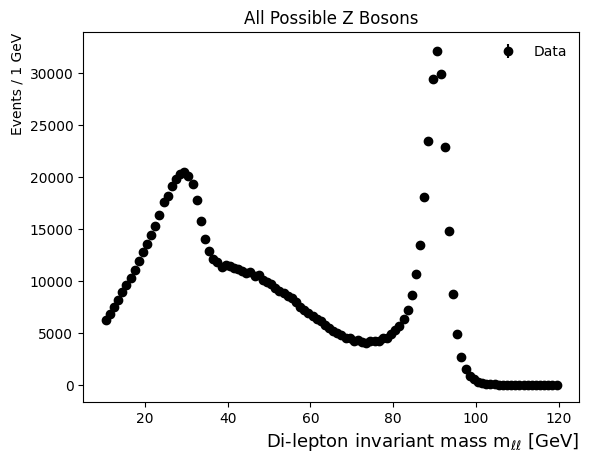

In [48]:
# x-axis range of the plot
xmin = 10 #GeV
xmax = 120 #GeV

# Histogram bin setup
bin_width = 1 #GeV
bin_edges = np.arange(start = xmin, stop = xmax + bin_width, step = bin_width)
bin_centers = bin_edges[:-1] + bin_width/2

# Creating histogram from data
counts, _ = np.histogram(Z_masses, bins = bin_edges)
count_errors = np.sqrt(counts) # poisson approximation of the error

# Plot
axs = plt.gca()
axs.errorbar(x = bin_centers, y = counts, yerr = count_errors,
                    fmt = 'ko', # 'k' means black and 'o' is for circles
                    label = 'Data')
axs.set_xlabel(r'Di-lepton invariant mass $\mathrm{m_{\ell\ell}}$ [GeV]', 
                     fontsize = 13, x = 1, horizontalalignment = 'right' )
axs.set_ylabel('Events / ' + str(bin_width) + ' GeV', y = 1, horizontalalignment = 'right')
plt.title('All Possible Z Bosons')
axs.legend(frameon = False)
plt.show()

 Notice two distinct peaks: one at 91 GeV as we would expect for Z bosons, and a second peak around 34 GeV. This lower peak is the off-shell Z boson peak. It is important that we see both of these peaks present because they suggest the existence of a Higgs boson decay.

Something important to note is that this data does not represent the real Z bosons that existed, but rather every possible combinations of leptons that could have resulted in a Z boson. In reality, there can only be at most two Z bosons in a given event (since we narrowed down to four leptons). More selections will narrow down our list of masses further so that all Higgs bosons we show truly existed.

### **Obtaining Higgs Masses**

Recall the somewhat strange order in which Z bosons were "stacked" to create Zs. The possible Z bosons combinations were:
- $Z_0 = \ell_0 + \ell_1$
- $Z_1 = \ell_0 + \ell_2$
- $Z_2 = \ell_0 + \ell_3$
- $Z_3 = \ell_1 + \ell_2$
- $Z_4 = \ell_1 + \ell_3$
- $Z_5 = \ell_2 + \ell_3$

Thus, the only combinations of Z bosons that yield a Higgs boson without double counting leptons are:
- $H_0 = Z_0 + Z_5 = (\ell_0 + \ell_1) + (\ell_2 + \ell_3)$
- $H_1 = Z_1 + Z_4 = (\ell_0 + \ell_2) + (\ell_1 + \ell_3)$
- $H_3 = Z_2 + Z_3 = (\ell_0 + \ell_3) + (\ell_1 + \ell_2)$

The array Zs was declared like so:

$\begin{bmatrix}
Z_0 \\ Z_1 \\ Z_2 \\ Z_5 \\ Z_4 \\ Z_3 \\
\end{bmatrix}$

Once split into two arrays, the corresponding Z bosons needed to form a Higgs boson are in the same array indices:

$\begin{bmatrix} Z_0 \\ Z_1 \\ Z_2 \end{bmatrix} + \begin{bmatrix} Z_5 \\ Z_4 \\ Z_3 \end{bmatrix} = \begin{bmatrix} H_0 \\ H_1 \\ H_2 \end{bmatrix}$

This property of corresponding Zs in the same indices will also allow us to very easily make cuts to an array of Higgs masses.

Because of the way we defined Zs, creating the Higgs array is simply the addition of the two halfs.

In [49]:
Higgs = Zs[:3] + Zs[3:]

Next, use *Z_mass* to create a cut to ensure that there is one on-shell and one off-shell Z boson per Higgs boson. The boundaries for these cuts are based on the Higgs boson discovery paper from 2012. There, they select for an on-shell Z boson with a mass between 50 GeV and 106 GeV and an off-shell Z boson that is between 17.5 GeV and 115GeV.

In [50]:
# split the array into two halfs
Z_mass_upper = Z_mass[:3]
Z_mass_lower = Z_mass[3:]

# define our mass constraints
Z_on_min, Z_on_max = 50, 106
Z_off_min, Z_off_max = 17.5, 115

# return true for all indices where a on\off shell pair exists
Z_up_is_on = (Z_mass_upper > Z_on_min) & (Z_mass_upper < Z_on_max)
Z_up_is_off = (Z_mass_upper > Z_off_min) & (Z_mass_upper < Z_off_max)
Z_low_is_on = (Z_mass_lower > Z_on_min) & (Z_mass_lower < Z_on_max)
Z_low_is_off = (Z_mass_lower > Z_off_min) & (Z_mass_lower < Z_off_max)

shell_cut = (Z_up_is_on & Z_low_is_off) | (Z_up_is_off & Z_low_is_on)

Below are cuts that ensure that the Z bosons which the Higgs boson decayed into both meet the charge, flavor, and tight ID conditions.

In [51]:
H_charge_cut = Z_charge_cut[:3] & Z_charge_cut[3:]
H_flavor_cut = Z_flavor_cut[:3] & Z_flavor_cut[3:]
H_tight_cut = Z_tight_cut[:3] & Z_tight_cut[3:]

*H_mass* is a 1D array of Higgs masses. While there are 3 possible combinations of leptons that yield a Higgs for every event, they all yield Higgs bosons of the same mass, so we only need to keep one row of masses. The only reason we are picky about the way the leptons are added was to make *shell_cut* to ensure that the Higgs were made of one on-shell Z and one off-shell Z.

In [52]:
H_mass = np.sqrt(np.abs(Higgs[:,0]**2-Higgs[:,1]**2-Higgs[:,2]**2-Higgs[:,3]**2))[0]

#### **Bonus Activity**

[The original discovery paper for the Higgs boson](https://www.sciencedirect.com/science/article/pii/S037026931200857X?via%3Dihub) includes several more intricate selections that you can apply to your notebooks to get better and better Higgs signals such as threshold on the transverse momentum and a more sophisticated on-shell off-shell mass constraint. Use leps and Zs to create these additional selections.

### **Plotting Higgs Masses**

Below is the application of the Higgs cuts to the Higgs array. Try different combinations of the cuts to see how the plot changes. The final array of Higgs masses will be one dimensional, since there can only be one Higgs created per event. To convert our 2D selections to a 1D selection, we will use the | operator to combine the different rows. For there to exist a valid Higgs boson in an event, only one of the rows needs to record *True*, so we use the | operator.

In [53]:
# choose cuts
cut = shell_cut & H_charge_cut & H_flavor_cut & H_tight_cut
# apply cuts
cut = cut[0] | cut[1] | cut[2]
H_mass = H_mass[cut]

The Higgs masses can be graphed using the same procedure as the Z masses. The only change is that the lower bound should be 110 GeV and the upper bound 160 GeV to capture the domain we expect to see the Higgs peak.

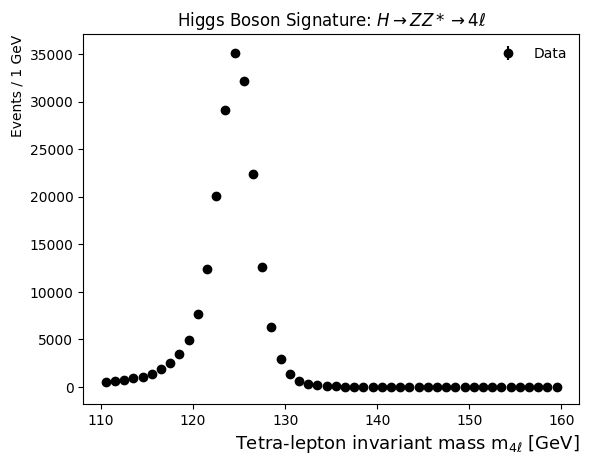

In [54]:
# x-axis range of the plot
xmin = 110 #GeV
xmax = 160 #GeV

# Histogram bin setup
bin_width = 1 #GeV
bin_edges = np.arange(start = xmin, stop = xmax + bin_width, step = bin_width)
bin_centers = bin_edges[:-1] + bin_width/2

# Creating histogram from data
counts, _ = np.histogram(H_mass, bins = bin_edges)
count_errors = np.sqrt(counts) # poisson approximation of the error

# Plot
axs = plt.gca()
axs.errorbar(x = bin_centers, y = counts, yerr = count_errors,
                    fmt = 'ko', # 'k' means black and 'o' is for circles
                    label = 'Data')
axs.set_xlabel(r'Tetra-lepton invariant mass $\mathrm{m_{4\ell}}$ [GeV]', 
                     fontsize = 13, x = 1, horizontalalignment = 'right' )
axs.set_ylabel('Events / ' + str(bin_width) + ' GeV', y = 1, horizontalalignment = 'right')
plt.title('Higgs Boson Signature: ' + r'$H \rightarrow ZZ* \rightarrow 4\ell$')
axs.legend(frameon = False)
plt.show()

#### **Bonus Activity**

High-energy physicists often like to add additional selections to split peaks into the portion constructed with only muons and the portion constructed with only electrons. Muons, due to their nature, produce higher resolution peaks then electrons. As an additional activity, use the array Higgs to create additional selections to H_mass. Use these selections to create plots of Higgs peaks for both channels and observe the difference in resolution.

## **Activity 3: Higgs Peak with Real Data**

In this activity, you will repeat the previous analysis but this time using real data. The procedure is similar to the previous activity.

We will use the same skim as Activity 2. We will swap the dataset idea for 'data' so that we are working with real data.

In [55]:
# this skim returns only events with 4 or more leptons per event
skim = "4lep"
files_list = atom.get_urls('data', skim, protocol='https', cache=True)

Unlike Activity 2, *files_list* contains more than one file. Where you can get away with only one file to get a distinct Z peak, the same can not be for a Higgs peak. You must open all 16 files, convert them into structured arrays, then concatenate them together using *np.concatenate()*. This can be accomplished by first defining an empty list *leps*, then entering a for-loop where each file is turned into a structured array and concatenated to leps like what is shown below. This cell will take a few minutes to compile on most systems; a formatted string within the loop will assure the user that the cell is running properly.

In [56]:
# empty array to be appended to in the for loop
leps = []

for file in files_list:
    print(f'Analyzing file: {file} ({files_list.index(file)+1}/{len(files_list)})')

    # open files and turn into a structured array
    analysis = uproot.open(file +':analysis')
    attributes = ['pt','eta','phi','e','charge','flavor','tight']
    aliases_dict = {'pt':'lep_pt','eta':'lep_eta','phi':'lep_phi','e':'lep_e',
                           'charge':'lep_charge','flavor':'lep_type','tight':'lep_isTightID'}
    leps_partial = analysis.arrays(attributes, aliases = aliases_dict)

    # append the current structured array to all previous structured arrays
    leps = np.concatenate([leps,leps_partial], axis=0)
print('Completed processing all files')

Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodD.4lep.root (1/16)
Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodE.4lep.root (2/16)
Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodF.4lep.root (3/16)
Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodG.4lep.root (4/16)
Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodH.4lep.root (5/16)
Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data15_periodJ.4lep.root (6/16)
Analyzing file: simplecache::https://opendata.cern.ch/eos/opendata/atlas/rucio/opendata/ODEO_FEB2025_v0_4lep_data16_periodA.4lep.root (7/16)
Analyzing fil

### **Analysis**

The process of creating an array of Higgs masses from the set of real data is the same as with the Monte Carlo data.

In [57]:
# sort leptons by transverse momentum, reduce number of leptons per event to 4
leps = leps[np.argsort(leps.pt, axis=1)[:,::-1]][:,:4]

# convert pt into px, py, pz
px = leps.pt*np.cos(leps.phi)
py = leps.pt*np.sin(leps.phi)
pz = leps.pt*np.sinh(leps.eta)

# Create an 3D Array of lepton attributes that can be easily sliced and
# added to form all possible Z Boson combinations
vecs = np.array([leps.e,px,py,pz,leps.charge,leps.flavor,leps.tight])

Z0 = vecs[:,:,0] + vecs[:,:,1]
Z1 = vecs[:,:,0] + vecs[:,:,2]
Z2 = vecs[:,:,0] + vecs[:,:,3]
Z3 = vecs[:,:,1] + vecs[:,:,2]
Z4 = vecs[:,:,1] + vecs[:,:,3]
Z5 = vecs[:,:,2] + vecs[:,:,3]
Zs = np.array([Z0,Z1,Z2,Z5,Z4,Z3])

Z_charge_cut = Zs[:,4] == 0
Z_flavor_cut = (Zs[:,5] == 22) | (Zs[:,5] == 26)
Z_tight_cut = Zs[:,6] == 2

Z_mass = np.sqrt(np.abs(Zs[:,0,:]**2-Zs[:,1,:]**2-Zs[:,2,:]**2-Zs[:,3,:]**2))

Try different combinations of cuts and see how the plot changes.

In [58]:
cut = Z_charge_cut & Z_flavor_cut & Z_tight_cut
cut_Z_mass = np.copy(Z_mass)
cut_Z_mass[~cut] = 0

Z_masses = np.ndarray.flatten(cut_Z_mass)
Z_masses = Z_masses[Z_masses != 0]

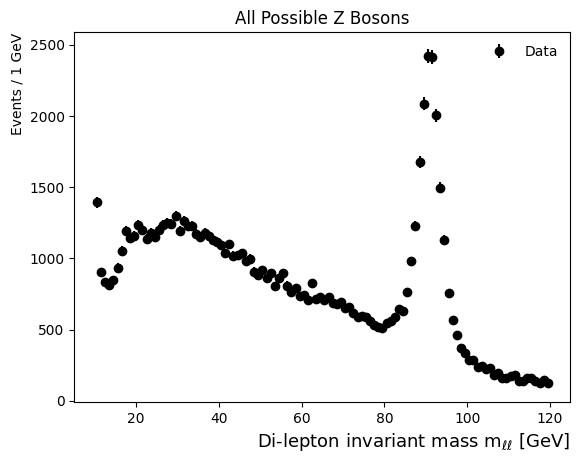

In [59]:
# x-axis range of the plot
xmin = 10 #GeV
xmax = 120 #GeV

# Histogram bin setup
bin_width = 1 #GeV
bin_edges = np.arange(start = xmin, stop = xmax + bin_width, step = bin_width)
bin_centers = bin_edges[:-1] + bin_width/2

# Creating histogram from data
counts, _ = np.histogram(Z_masses, bins = bin_edges)
count_errors = np.sqrt(counts) # poisson approximation of the error

# Plot
axs = plt.gca()
axs.errorbar(x = bin_centers, y = counts, yerr = count_errors,
                    fmt = 'ko', # 'k' means black and 'o' is for circles
                    label = 'Data')
axs.set_xlabel(r'Di-lepton invariant mass $\mathrm{m_{\ell\ell}}$ [GeV]', 
                     fontsize = 13, x = 1, horizontalalignment = 'right' )
axs.set_ylabel('Events / ' + str(bin_width) + ' GeV', y = 1, horizontalalignment = 'right')
plt.title('All Possible Z Bosons')
axs.legend(frameon = False)
plt.show()

In [60]:
Higgs = Zs[:3] + Zs[3:]

# split the array into two halfs
Z_mass_upper = Z_mass[:3]
Z_mass_lower = Z_mass[3:]

# define our mass constraints
Z_on_min, Z_on_max = 50, 106
Z_off_min, Z_off_max = 17.5, 115

# return true for all indices where a on\off shell pair exists
Z_up_is_on = (Z_mass_upper > Z_on_min) & (Z_mass_upper < Z_on_max)
Z_up_is_off = (Z_mass_upper > Z_off_min) & (Z_mass_upper < Z_off_max)
Z_low_is_on = (Z_mass_lower > Z_on_min) & (Z_mass_lower < Z_on_max)
Z_low_is_off = (Z_mass_lower > Z_off_min) & (Z_mass_lower < Z_off_max)

shell_cut = (Z_up_is_on & Z_low_is_off) | (Z_up_is_off & Z_low_is_on)

H_charge_cut = Z_charge_cut[:3] & Z_charge_cut[3:]
H_flavor_cut = Z_flavor_cut[:3] & Z_flavor_cut[3:]
H_tight_cut = Z_tight_cut[:3] & Z_tight_cut[3:]

H_mass = np.sqrt(np.abs(Higgs[:,0]**2-Higgs[:,1]**2-Higgs[:,2]**2-Higgs[:,3]**2))[0]

In [61]:
# choose cuts
cut = shell_cut & H_charge_cut & H_flavor_cut & H_tight_cut
# apply cuts
cut = cut[0] | cut[1] | cut[2]
H_mass = H_mass[cut]

When all of the cuts are applied, the counts per 1GeV will be low compared to the Monte Carlo data. To see a distinct peak at the mass of the Higgs boson, the bin width has been increased.

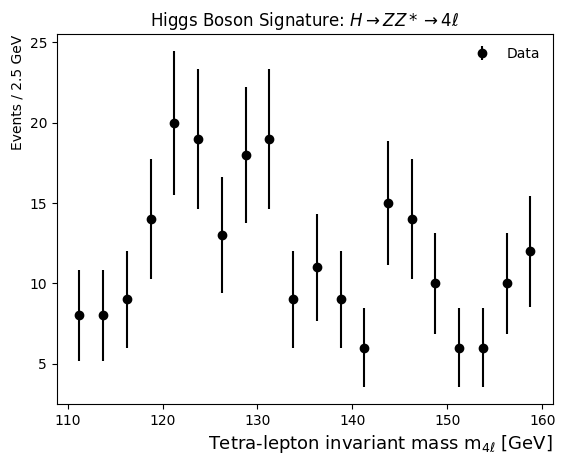

In [62]:
# x-axis range of the plot
xmin = 110 #GeV
xmax = 160 #GeV

# Histogram bin setup
bin_width = 2.5 #GeV
bin_edges = np.arange(start = xmin, stop = xmax + bin_width, step = bin_width)
bin_centers = bin_edges[:-1] + bin_width/2

# Creating histogram from data
counts, _ = np.histogram(H_mass, bins = bin_edges)
count_errors = np.sqrt(counts) # poisson approximation of the error

# Plot
axs = plt.gca()
axs.errorbar(x = bin_centers, y = counts, yerr = count_errors,
                    fmt = 'ko', # 'k' means black and 'o' is for circles
                    label = 'Data')
axs.set_xlabel(r'Tetra-lepton invariant mass $\mathrm{m_{4\ell}}$ [GeV]', 
                     fontsize = 13, x = 1, horizontalalignment = 'right' )
axs.set_ylabel('Events / ' + str(bin_width) + ' GeV', y = 1, horizontalalignment = 'right')
plt.title('Higgs Boson Signature: ' + r'$H \rightarrow ZZ* \rightarrow 4\ell$')
axs.legend(frameon = False)
plt.show()

## **Next Steps**

There is no shortage of additional activities that can be done with ATLAS Open Data. To continue analyzing the Higgs bososn through the 4 lepton channel, check out the [Higgs to ZZ](https://github.com/atlas-outreach-data-tools/notebooks-collection-opendata/blob/master/13-TeV-examples/uproot_python/HZZAnalysis.ipynb) tutorial. This activity will guide you through a different way of analyzing the Higgs boson and allow you to constuct all the various backgrounds which also produce 4 leptons as end results. 

After that, check out the wide array of other tutorials on [ATLAS Open Data's website](https://opendata.atlas.cern/docs/13TeV25Doc).

## **Acknowledgements**

Thank you to Dr. Zoya Vallari for providing me with the resources and guidance I needed to begin programming in ROOT and Python. Thank you to Omar Kotrach and Jacob Spiegel for their work on their exercise [ATLAS Open Data: Discovering the Z and Higgs Bosons](https://zenodo.org/records/10291091). I have based much of this exercise on their work. Thank you to Dr. Antonio Boveia who helped answer some questions I had about how the Higgs boson was discovered. I also thank everyone who proofread this exercise for errors, especially Stefan Ionascu, who was extremely helpful in his thorough review.

A special thanks goes to Osip Surdutovich for all the guidance he has given me on how to make this exercise and all the questions he has answered on how to create more intricate selections.